In [12]:
#Run if necessary
#%pip install medmnist
#%pip -m install dlordinal

In [3]:
#Import packages
from medmnist.dataset import RetinaMNIST
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import numpy as np

In [5]:
#import datasets, with high image quality to be able to see detailed images
train_data = RetinaMNIST(split='train', download=True, size=224)
val_data   = RetinaMNIST(split='val',   download=True, size=224)
test_data  = RetinaMNIST(split='test',  download=True, size=224)

Dataset RetinaMNIST of size 224 (retinamnist_224)
    Number of datapoints: 1080
    Root location: C:\Users\Aleksandra\.medmnist
    Split: train
    Task: ordinal-regression
    Number of channels: 3
    Meaning of labels: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
    Number of samples: {'train': 1080, 'val': 120, 'test': 400}
    Description: The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. The task is ordinal regression for 5-level grading of diabetic retinopathy severity. We split the source training set with a ratio of 9:1 into training and validation set, and use the source validation set as the test set. The source images of 3×1,736×1,824 are center-cropped and resized into 3×28×28.
    License: CC BY 4.0


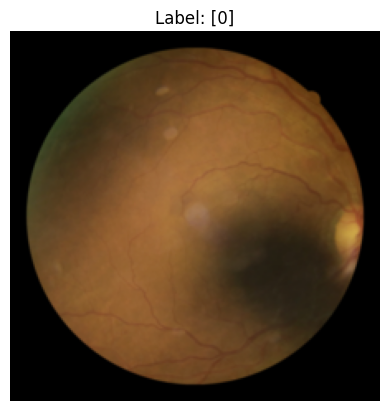

In [6]:
print(train_data) #There are 5 labels that classify increasing severity of diabetic retinopathy

#Example of an image
img, label = train_data[0]
plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [11]:
#Distribution of classifications in data. In each dataset, the distribution of classifications is similar.
splits = ["train", "val", "test"]
all_counts = {}
total_counts = Counter()
for split in splits:
    ds = RetinaMNIST(split=split, download=True)
    labels = [int(ds[i][1].item()) for i in range(len(ds))]
    all_counts[split] = Counter(labels)
    total_counts.update(labels)
    
for split in splits:
    print(f"\n{split.upper()} split:")
    for label, count in sorted(all_counts[split].items()):
        print(f"  Label {label}: {count} images")

print(f"\n Total over train, val and test:")
for label in sorted(total_counts.keys()):
    print(f"  Label {label}: {total_counts[label]} images")


TRAIN split:
  Label 0: 486 images
  Label 1: 128 images
  Label 2: 206 images
  Label 3: 194 images
  Label 4: 66 images

VAL split:
  Label 0: 54 images
  Label 1: 12 images
  Label 2: 28 images
  Label 3: 20 images
  Label 4: 6 images

TEST split:
  Label 0: 174 images
  Label 1: 46 images
  Label 2: 92 images
  Label 3: 68 images
  Label 4: 20 images

 Total over train, val and test:
  Label 0: 714 images
  Label 1: 186 images
  Label 2: 326 images
  Label 3: 282 images
  Label 4: 92 images
